In [1]:
#This code block contains the trainng and testing of linear regression model

In [11]:
pip install pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [11]:
file = "../Dataset/final_sdb_dataset_clean.csv"
df = pd.read_csv(file)
df_shallow = df[(df['depth'] >= 0) & (df['depth'] <= 30)].copy()


In [12]:
print(f"Original rows: {len(df)} | Rows after filtering (depth <= 30): {len(df_shallow)}")

Original rows: 11676 | Rows after filtering (depth <= 30): 4548


In [13]:
df_arabian_sea = df_shallow[(df_shallow['longitude'] > 48) & (df_shallow['longitude'] < 60)].copy()
df_strait_of_hormuz = df_shallow[(df_shallow['longitude'] > 65) & (df_shallow['longitude'] < 70)].copy()
df_bay_of_bengal = df_shallow[df_shallow['longitude'] >= 70].copy()

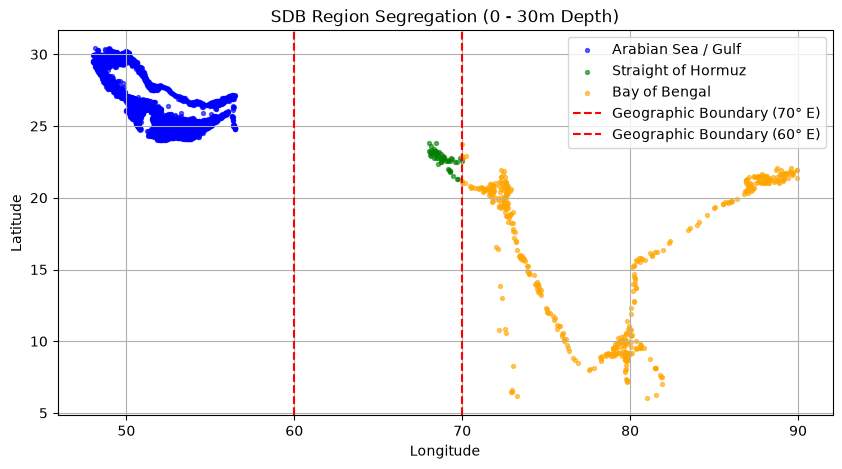

In [14]:
plt.figure(figsize=(10, 5))
plt.scatter(df_arabian_sea['longitude'], df_arabian_sea['latitude'], c='blue', label='Arabian Sea / Gulf', s=8, alpha=0.6)
plt.scatter(df_strait_of_hormuz['longitude'], df_strait_of_hormuz['latitude'], c='green', label='Straight of Hormuz', s=8, alpha=0.6)
plt.scatter(df_bay_of_bengal['longitude'], df_bay_of_bengal['latitude'], c='orange', label='Bay of Bengal', s=8, alpha=0.6)
plt.axvline(x=70, color='red', linestyle='--', label='Geographic Boundary (70° E)')
plt.axvline(x=60, color='red', linestyle='--', label='Geographic Boundary (60° E)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SDB Region Segregation (0 - 30m Depth)')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
features = ['blue_band', 
            'green_band', 
            'log_blue', 
            'log_green', 
            'bg_ratio', 
            'stumpf_ratio']

In [42]:
X_all = df_shallow[features]
y_all = df_shallow['depth']

In [43]:
X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

lr_global = LinearRegression()
lr_global.fit(X_tr_all, y_tr_all)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 9.51, -4.17,-32.93, 23.37,-77.2 ,489.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['blue_band','green_band','log_blue','log_green','bg_ratio','stumpf_ratio']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-426.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [44]:
y_pred_all = lr_global.predict(X_te_all)

In [45]:
mae_all = mean_absolute_error(y_te_all, y_pred_all)
rmse_all = root_mean_squared_error(y_te_all, y_pred_all)
r2_all = r2_score(y_te_all, y_pred_all)

print("=" * 45)
print("  GLOBAL MODEL: ALL REGIONS COMBINED")
print("=" * 45)
print(f"MAE  : {mae_all:.4f} m")
print(f"RMSE : {rmse_all:.4f} m")
print(f"R²   : {r2_all:.4f}\n")

  GLOBAL MODEL: ALL REGIONS COMBINED
MAE  : 5.3373 m
RMSE : 6.6804 m
R²   : 0.4334



  SEPARATE REGIONAL MODELS
=== Arabian Sea / Gulf (N=4067) ===
  MAE  : 4.9398 m
  RMSE : 6.2977 m
  R²   : 0.4780

=== Strait of Hormuz (N=54) ===
  MAE  : 3.8646 m
  RMSE : 5.1043 m
  R²   : 0.3284

=== Bay of Bengal (N=427) ===
  MAE  : 6.0030 m
  RMSE : 7.4287 m
  R²   : 0.2501



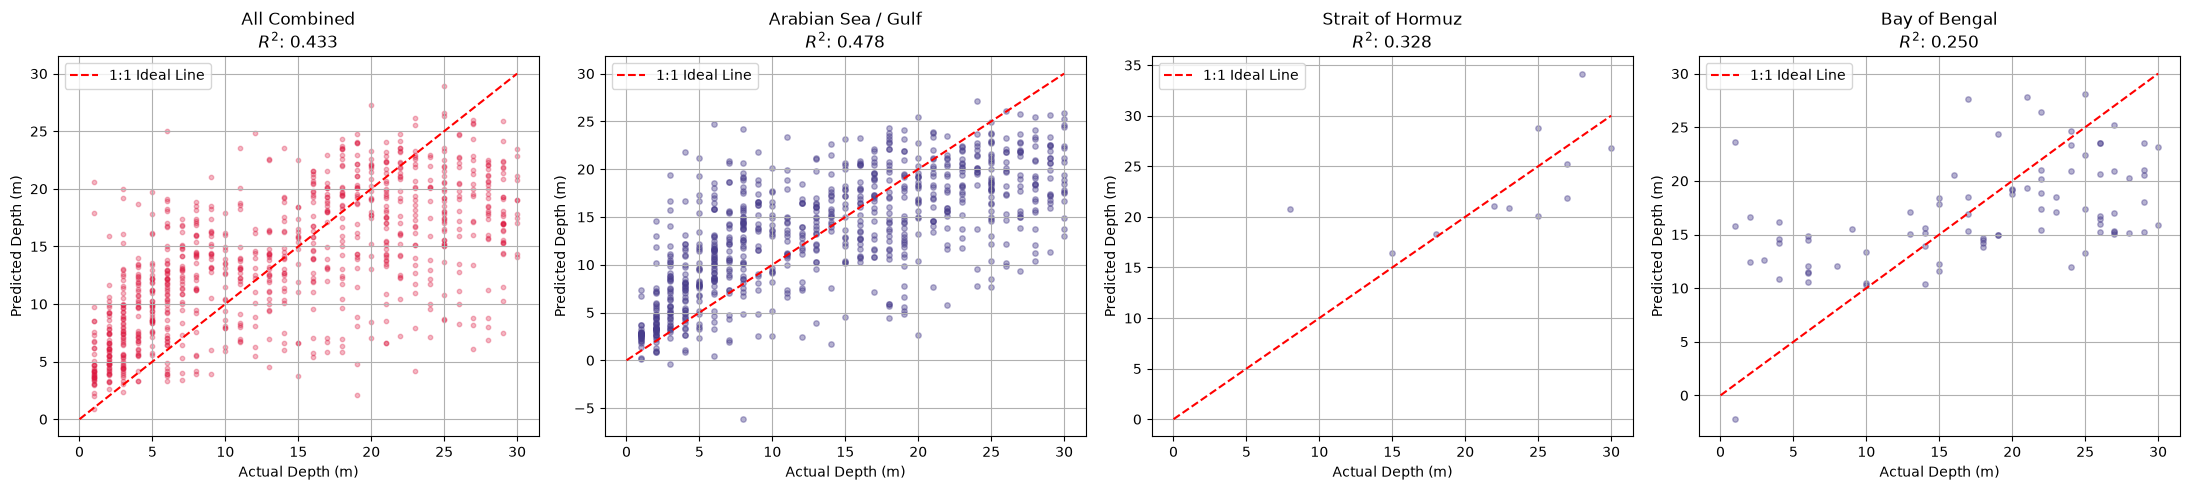

In [46]:
regions = [
    ('Arabian Sea / Gulf', df_arabian_sea),
    ('Strait of Hormuz', df_strait_of_hormuz),
    ('Bay of Bengal', df_bay_of_bengal)
]

lr_models = {}

print("=" * 45)
print("  SEPARATE REGIONAL MODELS")
print("=" * 45)

# Setup subplots: 1 row with 4 plots (Combined + 3 Regions)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot Combined Results in First Subplot
axes[0].scatter(y_te_all, y_pred_all, alpha=0.3, s=10, color='crimson')
axes[0].plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
axes[0].set_xlabel('Actual Depth (m)')
axes[0].set_ylabel('Predicted Depth (m)')
axes[0].set_title(f'All Combined\n$R^2$: {r2_all:.3f}')
axes[0].grid(True)
axes[0].legend()

# Iterate through individual regions
for idx, (name, region_df) in enumerate(regions, start=1):
    if len(region_df) == 0:
        print(f"Skipping {name}: No samples available.")
        continue
        
    X_reg = region_df[features]
    y_reg = region_df['depth']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    
    # Fit individual Linear Regression model
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_models[name] = lr
    
    # Predict & Evaluate
    y_pred = lr.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {name} (N={len(region_df)}) ===")
    print(f"  MAE  : {mae:.4f} m")
    print(f"  RMSE : {rmse:.4f} m")
    print(f"  R²   : {r2:.4f}\n")
    
    # Plot Region Results
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='darkslateblue')
    ax.plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
    ax.set_xlabel('Actual Depth (m)')
    ax.set_ylabel('Predicted Depth (m)')
    ax.set_title(f'{name}\n$R^2$: {r2:.3f}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()